In [3]:
import pandas as pd

df = pd.read_csv("../data/clean_airline_reviews.csv")

df.head()

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,...,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended,full_review_text,clean_review_text,processed_text,final_text
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,...,4.0,4.0,NaN,NaN,3.0,yes,"""pretty decent airline"" Moroni to Moheli. Tu...",pretty decent airline moroni to moheli turned ...,pretty decent airline moroni moheli turned pre...,pretty decent airline moroni moheli turned pre...
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,...,1.0,1.0,NaN,NaN,2.0,no,"""Not a good airline"" Moroni to Anjouan. It is...",not a good airline moroni to anjouan it is a v...,good airline moroni anjouan small airline tick...,good airline moroni anjouan small airline tick...
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,...,1.0,1.0,NaN,NaN,2.0,no,"""flight was fortunately short"" Anjouan to Dz...",flight was fortunately short anjouan to dzaoud...,flight fortunately short anjouan dzaoudzi smal...,flight fortunately short anjouan dzaoudzi smal...
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,...,NaN,1.0,NaN,NaN,1.0,no,"""I will never fly again with Adria"" Please d...",i will never fly again with adria please do a ...,never fly adria please favor fly adria route m...,never fly adria please favor fly adria route m...
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,...,1.0,1.0,1.0,1.0,1.0,no,"""it ruined our last days of holidays"" Do not ...",it ruined our last days of holidays do not boo...,ruined last days holidays book flight airline ...,ruined last day holiday book flight airline fr...


In [4]:
def severity_label(rating):
    if rating <= 2:
        return "Critical"
    elif rating <= 4:
        return "High"
    elif rating <= 6:
        return "Medium"
    else:
        return "Low"

df["Overall_Rating"] = pd.to_numeric(df["Overall_Rating"], errors="coerce")
df["severity_label"] = df["Overall_Rating"].apply(severity_label)

df["severity_label"].value_counts()

severity_label
Critical    13891
Low          5560
High         2215
Medium       1505
Name: count, dtype: int64

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["severity_id"] = le.fit_transform(df["severity_label"])

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df["final_text"])

sequences = tokenizer.texts_to_sequences(df["final_text"])

X = pad_sequences(sequences, maxlen=100)

y = df["severity_id"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()

model.add(Embedding(input_dim=10000, output_dim=128, input_length=100))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(4, activation='softmax'))

d:\Data science - Projects\airline-complaint-severity-detection\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/3
464/464 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.6803 - loss: 0.8747 - val_accuracy: 0.6950 - val_loss: 0.8112
Epoch 2/3
464/464 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.7350 - loss: 0.7061 - val_accuracy: 0.7122 - val_loss: 0.7821
Epoch 3/3
464/464 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.7818 - loss: 0.5902 - val_accuracy: 0.6961 - val_loss: 0.8355


In [10]:
loss, lstm_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", lstm_accuracy)
print("Test Loss:", loss)

145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6867 - loss: 0.8557
Test Accuracy: 0.6867313981056213
Test Loss: 0.8557325601577759


145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.87      0.82      2788
           1       0.19      0.09      0.12       421
           2       0.61      0.61      0.61      1118
           3       0.22      0.11      0.15       308

    accuracy                           0.69      4635
   macro avg       0.45      0.42      0.43      4635
weighted avg       0.64      0.69      0.66      4635


LSTM Precision: 0.6421667751498106
LSTM Recall: 0.6867313915857605
LSTM F1 Score: 0.6600039470702246


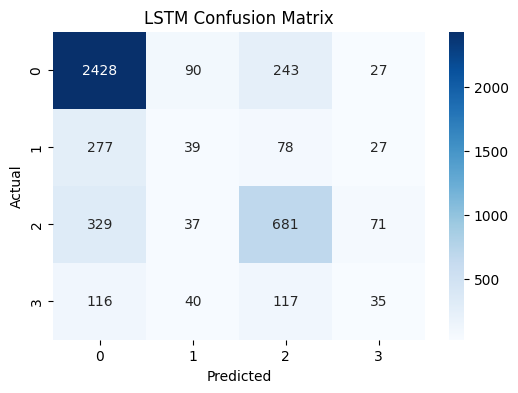

In [18]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Get predictions (probabilities)
y_pred_probs = model.predict(X_test)

# 2️⃣ Convert to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# 3️⃣ Classification report (FULL details)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 4️⃣ Individual metrics (for your results table)
lstm_precision = precision_score(y_test, y_pred, average='weighted')
lstm_recall = recall_score(y_test, y_pred, average='weighted')
lstm_f1 = f1_score(y_test, y_pred, average='weighted')

print("\nLSTM Precision:", lstm_precision)
print("LSTM Recall:", lstm_recall)
print("LSTM F1 Score:", lstm_f1)

# 5️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

cnn_model = Sequential()

cnn_model.add(Embedding(input_dim=10000, output_dim=128, input_length=100))

cnn_model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

cnn_model.add(GlobalMaxPooling1D())

cnn_model.add(Dense(64, activation='relu'))

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(4, activation='softmax'))

In [12]:
cnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [13]:
cnn_history = cnn_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/3
464/464 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.6762 - loss: 0.8859 - val_accuracy: 0.7060 - val_loss: 0.7856
Epoch 2/3
464/464 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7304 - loss: 0.7301 - val_accuracy: 0.7149 - val_loss: 0.7610
Epoch 3/3
464/464 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.7688 - loss: 0.5884 - val_accuracy: 0.7120 - val_loss: 0.7946


In [15]:
loss, cnn_accuracy = cnn_model.evaluate(X_test, y_test)

print("CNN Test Accuracy:", cnn_accuracy)

145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7077 - loss: 0.7892
CNN Test Accuracy: 0.707659125328064


145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

CNN Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.87      0.82      2788
           1       0.21      0.03      0.05       421
           2       0.58      0.74      0.65      1118
           3       0.00      0.00      0.00       308

    accuracy                           0.71      4635
   macro avg       0.39      0.41      0.38      4635
weighted avg       0.63      0.71      0.66      4635


CNN Precision: 0.6263112842219211
CNN Recall: 0.7076591154261057
CNN F1 Score: 0.6569064034689671


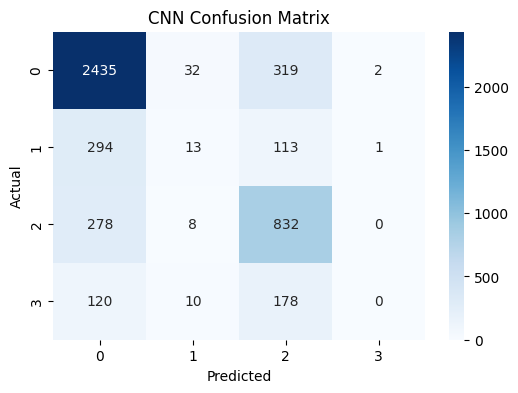

In [19]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Get predictions from CNN model
y_pred_probs = cnn_model.predict(X_test)

# 2️⃣ Convert to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# 3️⃣ Classification report
print("\nCNN Classification Report:\n")
print(classification_report(y_test, y_pred))

# 4️⃣ Individual metrics
cnn_precision = precision_score(y_test, y_pred, average='weighted')
cnn_recall = recall_score(y_test, y_pred, average='weighted')
cnn_f1 = f1_score(y_test, y_pred, average='weighted')

print("\nCNN Precision:", cnn_precision)
print("CNN Recall:", cnn_recall)
print("CNN F1 Score:", cnn_f1)

# 5️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
results_df = pd.read_csv("../models/model_results.csv")

new_results = pd.DataFrame({
    "Model": ["LSTM", "CNN"],
    "Accuracy": [lstm_accuracy, cnn_accuracy],
    "Precision": [lstm_precision, cnn_precision],
    "Recall": [lstm_recall, cnn_recall],
    "F1 Score": [lstm_f1, cnn_f1]
})

results_df = pd.concat([results_df, new_results], ignore_index=True)

# Save back to CSV
results_df.to_csv("../models/model_results.csv", index=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.646664,0.491140,0.540800,0.504593
1,Naive Bayes,0.717197,0.461949,0.427965,0.376047
2,SVM,0.705777,0.474021,0.442200,0.443481
3,LSTM,0.686731,0.642167,0.686731,0.660004
4,CNN,0.707659,0.626311,0.707659,0.656906
